<a href="https://colab.research.google.com/github/osoliman/DSC110/blob/main/Prediction/DSC110_Prediction_Model_Evaluation_Explanation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Model Evaluation and Explanation**

Model Evaluation

Evaluation of Classification models

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
X_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/X_train.csv')
X_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/X_test.csv')
y_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/y_train.csv')
y_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/y_test.csv')

#to prevent warning, converting the y from df to 1d series
y_train = y_train.squeeze()
y_test  = y_test.squeeze()

In [3]:
#Build the model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
#print(classification_report(y_test, y_pred, labels=[1]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1289
           1       0.29      0.06      0.11       216

    accuracy                           0.84      1505
   macro avg       0.58      0.52      0.51      1505
weighted avg       0.78      0.84      0.80      1505

AUC-ROC: 0.7488


==============================

ALL THE BELOW IS DEMO

You don't need to comment on it

Changing the threshold

In [ ]:
# Changing threshold to 0.3: classify as positive if prob >= 0.3
y_pred_03 = (y_prob >= 0.3).astype(int)

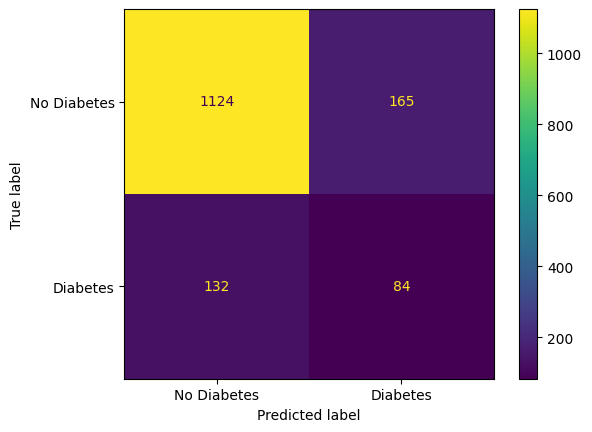

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_03, display_labels=['No Diabetes', 'Diabetes'])
plt.show()

In [ ]:
# Changing threshold to 0.7: classify as positive if prob >= 0.7
y_pred_07 = (y_prob >= 0.7).astype(int)

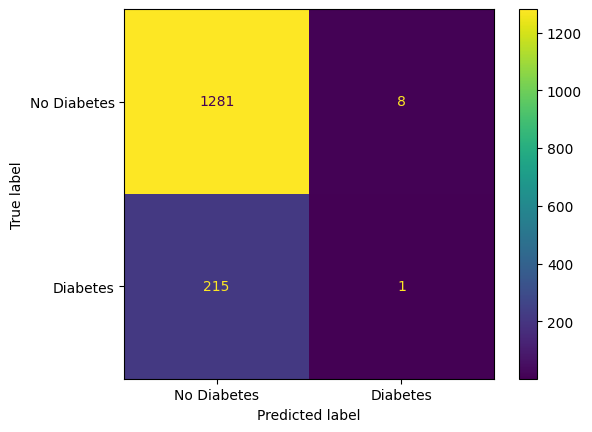

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_07, display_labels=['No Diabetes', 'Diabetes'])
plt.show()

Explainability

SHAP

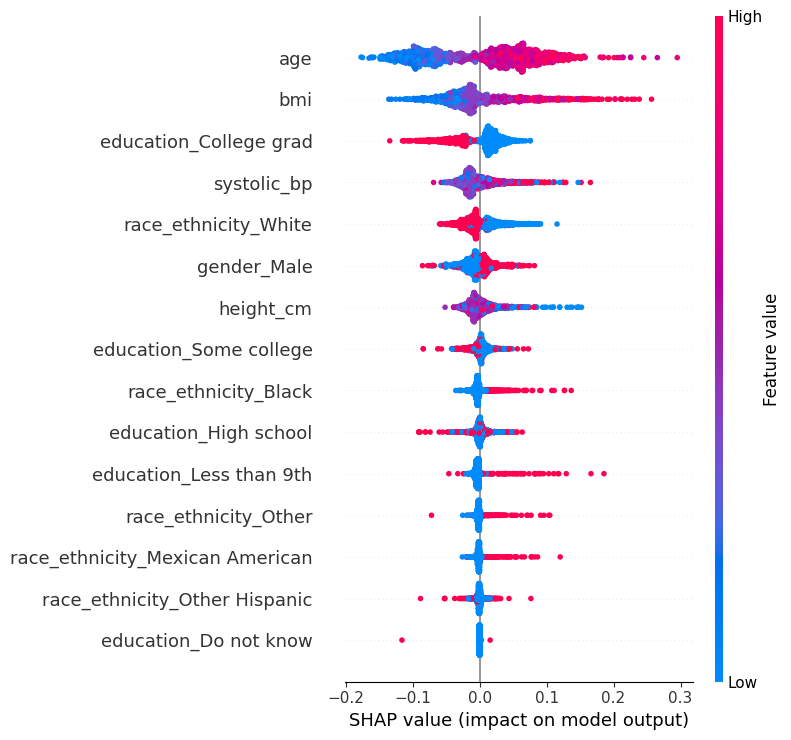

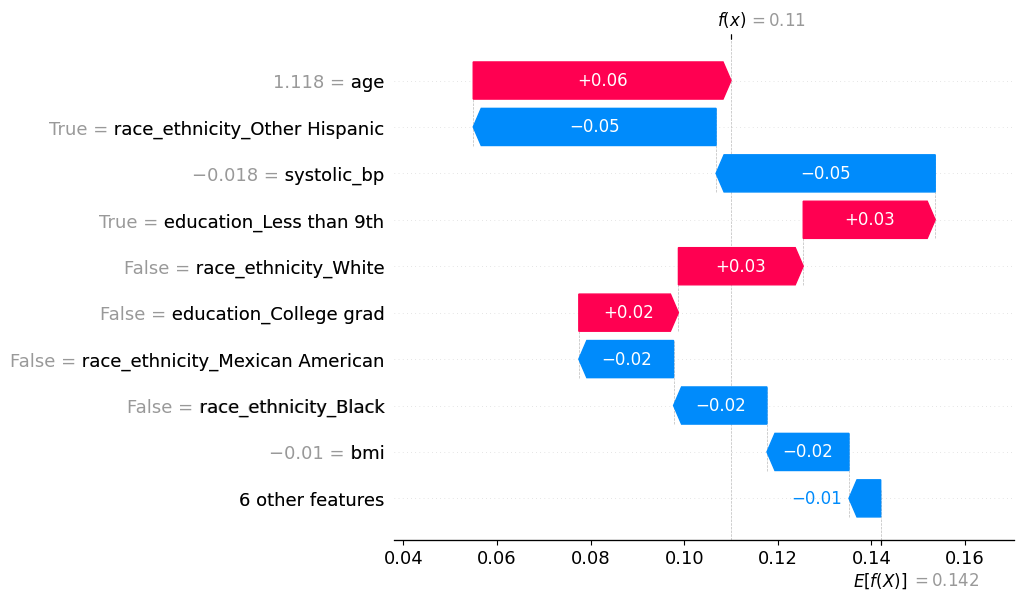

In [5]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test)          # newer API — returns Explanation object

# overall summary plot
shap.summary_plot(shap_values[:, :, 1], X_test)   # [:, :, 1] = all rows, all features, positive class

# single observation (row 0)
shap.plots.waterfall(shap_values[0, :, 1])         # cleaner than force_plot for single obs

Partial Dependence Plot (PDP)

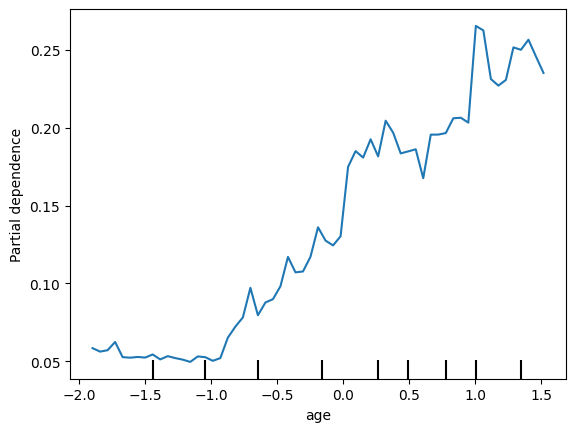

In [6]:
from sklearn.inspection import PartialDependenceDisplay

# replace 'age' with any feature name (or column index)
PartialDependenceDisplay.from_estimator(
    rf,
    X_test,
    features=['age']          # list of features to plot
)

Feature Importance Plot

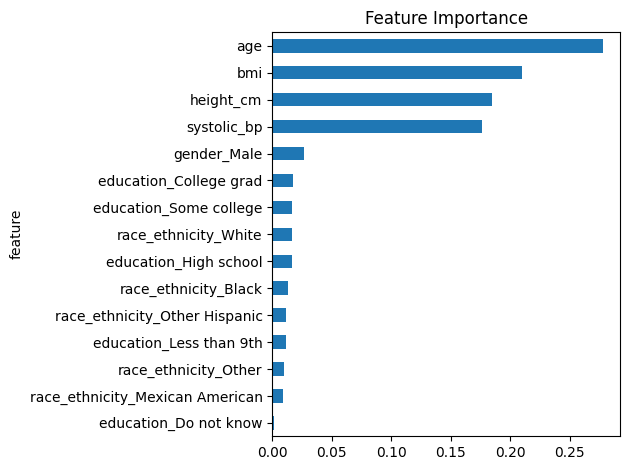

In [7]:
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

importance_df.plot(
    kind='barh',
    x='feature', y='importance',
    legend=False, title='Feature Importance'
)
plt.tight_layout()
plt.show()

Auto ML

In [9]:
pip install h2o

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.4/266.4 MB 4.4 MB/s eta 0:00:00


In [11]:
import h2o
from h2o.automl import H2OAutoML

h2o.init()

# convert your existing splits
train = h2o.H2OFrame(X_train.assign(target=y_train))
test  = h2o.H2OFrame(X_test.assign(target=y_test))

x = X_train.columns.tolist()
y = 'target'

train['target'] = train['target'].asfactor()
test['target']  = test['target'].asfactor()

aml = H2OAutoML(max_models=10, seed=42)
aml.train(x=x, y=y, training_frame=train)

# leaderboard
aml.leaderboard.head()

# best model predictions
preds = aml.leader.predict(test)

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,1 min 17 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,12 days
H2O_cluster_name:,H2O_from_python_unknownUser_36t5ei
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.146 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


In [13]:
aml.leaderboard.head()

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
StackedEnsemble_BestOfFamily_1_AutoML_2_20260324_171348,0.767293,0.350734,0.311718,0.315215,0.329683,0.108691
StackedEnsemble_AllModels_1_AutoML_2_20260324_171348,0.766339,0.351153,0.310419,0.32028,0.329881,0.108822
GBM_1_AutoML_2_20260324_171348,0.762645,0.35268,0.30575,0.311256,0.330413,0.109173
GLM_1_AutoML_2_20260324_171348,0.759653,0.354654,0.307912,0.310711,0.331129,0.109647
XGBoost_3_AutoML_2_20260324_171348,0.750242,0.364387,0.291629,0.319479,0.336064,0.112939
GBM_2_AutoML_2_20260324_171348,0.746515,0.361157,0.283594,0.326361,0.334452,0.111858
XGBoost_1_AutoML_2_20260324_171348,0.746264,0.368353,0.285342,0.325235,0.337847,0.114141
GBM_3_AutoML_2_20260324_171348,0.74545,0.362089,0.296462,0.321436,0.334017,0.111567
XRT_1_AutoML_2_20260324_171348,0.738048,0.372291,0.280878,0.310197,0.336078,0.112948
GBM_4_AutoML_2_20260324_171348,0.732616,0.368902,0.27834,0.330702,0.336916,0.113512
